In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [9]:
# 1. LOAD AND PREPROCESS DATA
# ==========================================
# Loading top 10,000 most frequent words
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0  # Multi-hot encoding
    return results

X_train = vectorize_sequences(X_train_raw)
X_test = vectorize_sequences(X_test_raw)
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# 2. BUILD THE DEEP NEURAL NETWORK
# ==========================================
model = Sequential([
    Dense(16, activation='relu', input_shape=(10000,)),
    Dropout(0.5), # Added to prevent the overfitting seen in your previous run
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification (0 to 1)
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# 3. TRAINING WITH VALIDATION
# ==========================================
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=512,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.6993 - loss: 0.5932 - val_accuracy: 0.8616 - val_loss: 0.4153
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8472 - loss: 0.3935 - val_accuracy: 0.8844 - val_loss: 0.3067
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8936 - loss: 0.2979 - val_accuracy: 0.8892 - val_loss: 0.2753
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9160 - loss: 0.2429 - val_accuracy: 0.8934 - val_loss: 0.2695
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9294 - loss: 0.2073 - val_accuracy: 0.8908 - val_loss: 0.2767
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9418 - loss: 0.1754 - val_accuracy: 0.8936 - val_loss: 0.2808
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9504 - loss: 0.1496 - val_accuracy: 0.8926 - val_loss: 0.2922
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9564 - loss: 0.1305 - val_accuracy: 0.8922 - v

In [13]:
# 4. VISUALIZE TRAINING PROGRESS
# ==========================================
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

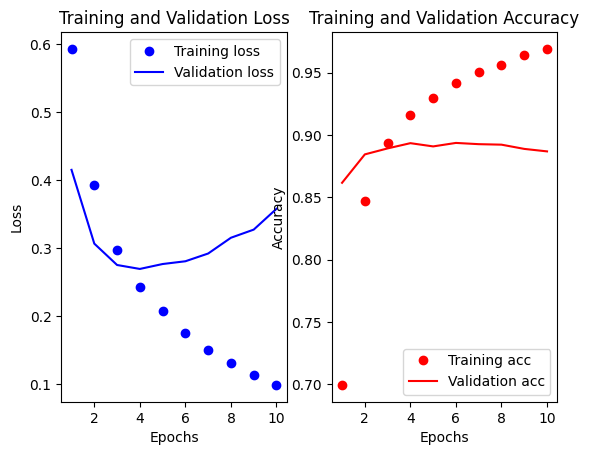

In [14]:
# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

 # Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'ro', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Test Loss: 0.3793
Test Accuracy: 0.8782
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



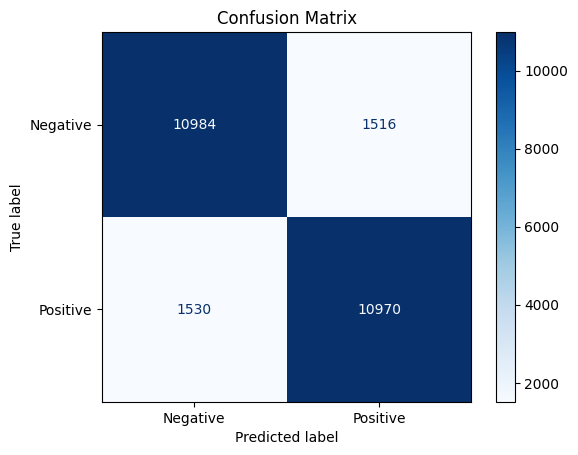

In [15]:
# 5. FINAL EVALUATION & RESULTS
# ==========================================
# Evaluate on unseen test data
results = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

# Generate Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()